In [2]:
!pip install --quiet pandas numpy scikit-learn tqdm joblib matplotlib seaborn torch torchvision torchaudio

In [3]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import glob
import re
import fileinput
from google.colab import drive

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive_repo_path = "../TimeGAN-pytorch"
DRIVE_DATA_PATH = '../data/processed/signals/'
SAVE_PATH = '../data/GAN_Output/'
os.makedirs(SAVE_PATH, exist_ok=True)
REPO_DATA_PATH = os.path.join(drive_repo_path, "data/ecg")
os.makedirs(REPO_DATA_PATH, exist_ok=True)

Kullanılacak Cihaz: cuda
Mounted at /content/drive

Ortam ayarlandı, kütüphaneler kuruldu/kontrol edildi ve Drive bağlandı.
PyTorch için GPU bulundu.


In [5]:
os.chdir(drive_repo_path)

from utils import extract_time, random_generator, NormMinMax
sys.path.append('lib')
from model import Generator, Recovery, Encoder, Discriminator, Supervisor

Çalışma dizini '/content/drive/MyDrive/Colab_ECG_Data/TimeGAN-pytorch' olarak değiştirildi.

Repo İçeriği (kontrol):
total 41
-rw------- 1 root root  7297 Oct 26 20:40 data.py
-rw------- 1 root root     0 Oct 25 12:45 __init__.py
drwx------ 2 root root  4096 Oct 25 12:45 metrics
-rw------- 1 root root  5379 Oct 25 12:45 model.py
drwx------ 2 root root  4096 Oct 25 12:51 __pycache__
-rw------- 1 root root 19617 Oct 26 21:27 timegan.py
utils modülü başarıyla import edildi.
lib/model modülleri başarıyla import edildi.


In [6]:
X_train_sig_orig = np.load(os.path.join(DRIVE_DATA_PATH, 'X_train_sig.npy'))
y_train_orig = np.load(os.path.join(DRIVE_DATA_PATH, 'y_train.npy'))

unique_classes, counts = np.unique(y_train_orig, return_counts=True)
class_distribution = dict(zip(unique_classes, counts))

majority_class_label = max(class_distribution, key=class_distribution.get)
majority_class_count = class_distribution[majority_class_label]

minority_classes = [label for label in unique_classes if label != majority_class_label]

seq_len = X_train_sig_orig.shape[1]
n_features = X_train_sig_orig.shape[2]

Orijinal eğitim verisi yükleniyor...
Orijinal eğitim verisi yüklendi. X_train boyutu: (136883, 250, 12)

Orijinal sınıf dağılımı: {np.int64(0): np.int64(17216), np.int64(1): np.int64(8422), np.int64(2): np.int64(35002), np.int64(3): np.int64(60883), np.int64(4): np.int64(15360)}
Çoğunluk sınıfı: Etiket = 3, Örnek Sayısı = 60883
Dengelenecek Azınlık Sınıfları: [np.int64(0), np.int64(1), np.int64(2), np.int64(4)]
seq_len=250, n_features=12


In [7]:
# --- HÜCRE 4: Azınlık Sınıfları İçin GAN Eğitim Döngüsü (KALDIĞI YERDEN) ---
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import joblib

# Gerekli değişkenleri yükle
try:
    %store -r X_train_sig_orig y_train_orig seq_len n_features SAVE_PATH DRIVE_DATA_PATH class_distribution
    print("Gerekli değişkenler yüklendi.")
except NameError:
    print("Hata: Gerekli değişkenler bulunamadı. Lütfen Hücre 3'ü tekrar çalıştırın.")
    raise SystemExit("Değişkenler eksik.")
except Exception as e:
    print(f"Değişkenler yüklenirken hata: {e}")
    raise SystemExit("Devam edilemiyor.")

# --- EN ÖNEMLİ DEĞİŞİKLİK ---
# Sınıf 0 ve 1 bitti. Sadece kalan 2 ve 4'ü eğitiyoruz.
minority_classes_to_train = [2, 4]
print(f"KALAN SINIFLAR: Eğitim Sınıf {minority_classes_to_train[0]}'den başlayarak devam edecek...")
# --- DEĞİŞİKLİK SONU ---

# Repo içindeki geçici veri dosyasının adı
temp_data_filename = "current_minority_data.npy"
REPO_DATA_PATH = "data/ecg"
temp_data_filepath = os.path.join(REPO_DATA_PATH, temp_data_filename)

# Eğitim parametreleri (Aynı)
iterations = 15000
batch_size = 128
hidden_dim = 192
num_layer = 3
z_dim = 12
learning_rate = 0.0005
print_freq = 500

# Yeni, kısaltılmış liste üzerinden döngü
for current_class_label in minority_classes_to_train:
    print(f"\n{'='*20} AZINLIK SINIFI {current_class_label} İÇİN EĞİTİM {'='*20}")

    # 1. O sınıfa ait veriyi hazırla ve geçici dosyaya kaydet
    print(f"  Sınıf {current_class_label} verisi hazırlanıyor...")
    class_signals = X_train_sig_orig[y_train_orig == current_class_label]

    scaler = MinMaxScaler(feature_range=(-1, 1))
    n_s, s_l, n_f = class_signals.shape
    data_reshaped = class_signals.reshape(-1, n_f)
    data_scaled = scaler.fit_transform(data_reshaped)
    data_scaled = data_scaled.reshape(n_s, s_l, n_f)

    np.save(temp_data_filepath, data_scaled)
    print(f"  Sınıf {current_class_label} verisi '{temp_data_filepath}' dosyasına kaydedildi. Boyut: {data_scaled.shape}")

    scaler_filename = os.path.join(SAVE_PATH, f'gan_scaler_class_{current_class_label}.pkl')
    joblib.dump(scaler, scaler_filename)
    print(f"  Scaler '{scaler_filename}' adresine kaydedildi.")

    # 2. Modeli eğit (train.py'yi çalıştır)
    model_save_path = os.path.join(SAVE_PATH, f'timegan_pytorch_trained_class_{current_class_label}')
    os.makedirs(model_save_path, exist_ok=True)

    print(f"\n  Sınıf {current_class_label} için TimeGAN eğitimi başlıyor ({iterations} iterasyon)...")

    !python train.py \
        --data_name ecg \
        --seq_len {seq_len} \
        --hidden_dim {hidden_dim} \
        --num_layer {num_layer} \
        --z_dim {z_dim} \
        --iteration {iterations} \
        --batch_size {batch_size} \
        --module gru \
        --lr {learning_rate} \
        --outf "{model_save_path}" \
        --workers 2 \
        --print_freq {print_freq}

    print(f"\n  Sınıf {current_class_label} için eğitim tamamlandı.")

# Geçici veri dosyasını sil
if os.path.exists(temp_data_filepath):
    os.remove(temp_data_filepath)
    print(f"\nGeçici veri dosyası '{temp_data_filepath}' silindi.")

print("\n\n--- TÜM AZINLIK SINIFLARI İÇİN GAN EĞİTİMLERİ TAMAMLANDI ---")

no stored variable or alias X_train_sig_orig
no stored variable or alias y_train_orig
no stored variable or alias seq_len
no stored variable or alias n_features
no stored variable or alias SAVE_PATH
no stored variable or alias DRIVE_DATA_PATH
no stored variable or alias class_distribution
Gerekli değişkenler yüklendi.
KALAN SINIFLAR: Eğitim Sınıf 2'den başlayarak devam edecek...

==================== AZINLIK SINIFI 2 İÇİN EĞİTİM ====================
  Sınıf 2 verisi hazırlanıyor...
  Sınıf 2 verisi 'data/ecg/current_minority_data.npy' dosyasına kaydedildi. Boyut: (35002, 250, 12)
  Scaler '/content/drive/MyDrive/Colab_ECG_Data/GAN_Output/gan_scaler_class_2.pkl' adresine kaydedildi.

  Sınıf 2 için TimeGAN eğitimi başlıyor (15000 iterasyon)...
Loading custom ECG data...
Loading from: data/ecg/minority_class_1.npy
Loaded ECG data with shape: (8422, 250, 12)
ECG data shuffled and converted to list format (length: 8422)
'ecg' dataset is ready. Number of samples: 8422
TimeGAN BaseModel usin

In [8]:
# --- HÜCRE 5: Tüm Azınlık Sınıfları İçin Sentetik Veri Üretme (Seçenek B'ye Göre) ---

print("\n--- Tüm Azınlık Sınıfları İçin Sentetik Veri Üretme (Hedef: ~%35/23/16/13/13) ---")

# Gerekli değişkenleri yükle
try:
    %store -r minority_classes class_distribution majority_class_label majority_class_count seq_len n_features SAVE_PATH device DRIVE_DATA_PATH # DRIVE_DATA_PATH eklendi
    print("Gerekli değişkenler yüklendi.")

    # Model tanımlarını import et
    try:
        # Çalışma dizini hala repo ana dizini olmalı
        # sys.path.append('lib') # Hücre 2'de eklenmiş olmalı
        from model import Generator, Recovery
        print("Generator ve Recovery modülleri import edildi.")
    except Exception as e:
        print(f"Hata: Generator/Recovery import edilemedi: {e}")
        raise SystemExit("Modüller bulunamadı.")

    # --- YENİ: Hedef Sayıları Hesapla ---
    target_total_samples = int(majority_class_count / 0.35) # Hedef toplam örnek sayısı
    target_counts = {
        0: int(target_total_samples * 0.16), # CD
        1: int(target_total_samples * 0.13), # HYP
        2: int(target_total_samples * 0.23), # MI
        3: majority_class_count,            # NORM
        4: int(target_total_samples * 0.13)  # STTC
    }
    print("\nHedeflenen Örnek Sayıları (Yaklaşık):", target_counts)
    # --- YENİ SON ---

except NameError:
    print("Hata: Gerekli değişkenler bulunamadı. Lütfen Hücre 3'ü tekrar çalıştırın.")
    raise SystemExit("Değişkenler eksik.")
except Exception as e:
    print(f"Başlangıçta hata: {e}")
    raise SystemExit("Devam edilemiyor.")

all_synthetic_signals = []
all_synthetic_labels = []

# Her azınlık sınıfı için döngü
for current_class_label in minority_classes:
    print(f"\n{'='*10} Sınıf {current_class_label} İçin Veri Üretiliyor {'='*10}")

    current_class_count = class_distribution[current_class_label]
    target_class_count = target_counts[current_class_label] # Yeni hedef sayısını al
    n_synthetic_needed = target_class_count - current_class_count # Üretilecek miktarı hesapla

    if n_synthetic_needed <= 0:
        print(f"  Sınıf {current_class_label} zaten hedef sayıda ({target_class_count}) veya daha fazla örneğe sahip. Üretim atlanıyor.")
        continue

    print(f"  Orijinal: {current_class_count}, Hedef: {target_class_count} => Üretilecek: {n_synthetic_needed}")

    # Eğitilmiş modelin ağırlıklarının yolu
    model_ana_klasoru = f'timegan_pytorch_trained_class_{current_class_label}'
    trained_model_weights_dir = os.path.join(SAVE_PATH, model_ana_klasoru, 'TimeGAN', 'ecg', 'train', 'weights')

    # En son Generator ve Recovery modellerini bul
    try:
        # iterations değişkeni Hücre 4'ten gelmeli, %store ile kaydedilmediyse tekrar tanımla
        if 'iterations' not in locals(): iterations = 15000

        gen_model_files = glob.glob(os.path.join(trained_model_weights_dir, f"netG_iter_{iterations-1}.pth"))
        if not gen_model_files: raise FileNotFoundError(f"Generator iter={iterations-1}")
        latest_gen_model_path = gen_model_files[0]

        rec_model_files = glob.glob(os.path.join(trained_model_weights_dir, f"netR_iter_{iterations-1}.pth"))
        if not rec_model_files: raise FileNotFoundError(f"Recovery iter={iterations-1}")
        latest_rec_model_path = rec_model_files[0]
        print(f"  Kullanılacak modeller bulundu.")
    except FileNotFoundError as e:
        print(f"  HATA: Sınıf {current_class_label} için eğitilmiş {e} modeli bulunamadı ({trained_model_weights_dir}). Bu sınıf atlanıyor.")
        continue
    except Exception as e:
        print(f"  HATA: Model dosyaları aranırken hata: {e}. Bu sınıf atlanıyor.")
        continue

    # --- Manuel Üretme Kodu ---
    try:
        # Geçici options nesnesi
        class TempOpt: z_dim=z_dim; hidden_dim=hidden_dim; num_layer=num_layer; seq_len=seq_len; n_features=n_features; module='gru'
        opt_temp = TempOpt()

        # Modelleri oluştur ve ağırlıkları yükle
        generator = Generator(opt_temp).to(device)
        generator.load_state_dict(torch.load(latest_gen_model_path, map_location=device)['state_dict'])
        generator.eval()

        recovery = Recovery(opt_temp).to(device)
        recovery.load_state_dict(torch.load(latest_rec_model_path, map_location=device)['state_dict'])
        recovery.eval()

        generated_data_scaled = []
        current_batch_size = 128
        with torch.no_grad():
            # Tam olarak n_synthetic_needed kadar üretmek için adım sayısını ayarla
            steps = int(np.ceil(n_synthetic_needed / current_batch_size))
            print(f"  {steps} adımda üretim yapılacak...")
            for _ in trange(steps, desc=f'Sınıf {current_class_label} üretimi', leave=False):
                # Son adımda sadece kalan miktar kadar üretmek için batch size'ı ayarla
                batch_needed = min(n_synthetic_needed - len(np.concatenate(generated_data_scaled, axis=0)) if generated_data_scaled else n_synthetic_needed, current_batch_size)
                if batch_needed <= 0: break # Eğer yeterince ürettiysek döngüden çık

                noise = torch.randn(batch_needed, seq_len, opt_temp.z_dim, device=device)
                batch_synthetic_hidden = generator(noise)
                batch_synthetic_scaled = recovery(batch_synthetic_hidden)
                generated_data_scaled.append(batch_synthetic_scaled.cpu().numpy())

        # Birleştir (Artık kırpmaya gerek yok, tam sayıda üretildi)
        synthetic_data_scaled = np.concatenate(generated_data_scaled, axis=0)
        print(f"  Sınıf {current_class_label} için {synthetic_data_scaled.shape[0]} ölçekli sentetik veri üretildi.")

        # Scaler'ı yükle ve geri dönüştür
        scaler_filename = os.path.join(SAVE_PATH, f'gan_scaler_class_{current_class_label}.pkl')
        scaler_loaded = joblib.load(scaler_filename)

        n_s, s_l, n_f = synthetic_data_scaled.shape
        synthetic_reshaped = synthetic_data_scaled.reshape(-1, n_f)
        synthetic_unscaled = scaler_loaded.inverse_transform(synthetic_reshaped)
        synthetic_signals = synthetic_unscaled.reshape(n_s, s_l, n_f)
        print("  Sentetik sinyaller orijinal ölçeğine geri dönüştürüldü.")

        # Toplu listelere ekle
        all_synthetic_signals.append(synthetic_signals)
        all_synthetic_labels.append(np.full(n_s, current_class_label))

    except Exception as e:
        print(f"  HATA: Sınıf {current_class_label} için üretim sırasında hata: {e}")

# Döngü bittikten sonra tüm üretilen verileri birleştir
if all_synthetic_signals:
    final_synthetic_signals = np.concatenate(all_synthetic_signals, axis=0)
    final_synthetic_labels = np.concatenate(all_synthetic_labels, axis=0)
    print(f"\nToplam {final_synthetic_signals.shape[0]} adet sentetik sinyal üretildi.") # Bu 37,069 olmalı

    # Sonuçları Drive'a kaydet
    final_signals_path = os.path.join(SAVE_PATH, 'synthetic_signals_all_minority_B.npy') # İsimde B olsun
    final_labels_path = os.path.join(SAVE_PATH, 'synthetic_labels_all_minority_B.npy')
    np.save(final_signals_path, final_synthetic_signals)
    np.save(final_labels_path, final_synthetic_labels)
    print(f"Tüm sentetik sinyaller '{final_signals_path}' adresine kaydedildi.")
    print(f"Tüm sentetik etiketler '{final_labels_path}' adresine kaydedildi.")
else:
    print("\nHiç sentetik veri üretilemedi.")
    final_synthetic_labels = np.array([])

# Görselleştirme hücresini çalıştırmadan önce %store ile değişkenleri kaydedebiliriz
# %store final_synthetic_labels


--- Tüm Azınlık Sınıfları İçin Sentetik Veri Üretme (Hedef: ~%35/23/16/13/13) ---
no stored variable or alias minority_classes
no stored variable or alias class_distribution
no stored variable or alias majority_class_label
no stored variable or alias majority_class_count
no stored variable or alias seq_len
no stored variable or alias n_features
no stored variable or alias SAVE_PATH
no stored variable or alias device
no stored variable or alias DRIVE_DATA_PATH
no stored variable or alias #
no stored variable or alias DRIVE_DATA_PATH
no stored variable or alias eklendi
Gerekli değişkenler yüklendi.
Generator ve Recovery modülleri import edildi.

Hedeflenen Örnek Sayıları (Yaklaşık): {0: 27832, 1: 22613, 2: 40008, 3: np.int64(60883), 4: 22613}

========== Sınıf 0 İçin Veri Üretiliyor ==========
  Orijinal: 17216, Hedef: 27832 => Üretilecek: 10616
  Kullanılacak modeller bulundu.
  83 adımda üretim yapılacak...


  Sınıf 0 için 10616 ölçekli sentetik veri üretildi.
  Sentetik sinyaller orijinal ölçeğine geri dönüştürüldü.

========== Sınıf 1 İçin Veri Üretiliyor ==========
  Orijinal: 8422, Hedef: 22613 => Üretilecek: 14191
  Kullanılacak modeller bulundu.
  111 adımda üretim yapılacak...


  Sınıf 1 için 14191 ölçekli sentetik veri üretildi.
  Sentetik sinyaller orijinal ölçeğine geri dönüştürüldü.

========== Sınıf 2 İçin Veri Üretiliyor ==========
  Orijinal: 35002, Hedef: 40008 => Üretilecek: 5006
  Kullanılacak modeller bulundu.
  40 adımda üretim yapılacak...


  Sınıf 2 için 5006 ölçekli sentetik veri üretildi.
  Sentetik sinyaller orijinal ölçeğine geri dönüştürüldü.

========== Sınıf 4 İçin Veri Üretiliyor ==========
  Orijinal: 15360, Hedef: 22613 => Üretilecek: 7253
  Kullanılacak modeller bulundu.
  57 adımda üretim yapılacak...


  Sınıf 4 için 7253 ölçekli sentetik veri üretildi.
  Sentetik sinyaller orijinal ölçeğine geri dönüştürüldü.

Toplam 37066 adet sentetik sinyal üretildi.
Tüm sentetik sinyaller '/content/drive/MyDrive/Colab_ECG_Data/GAN_Output/synthetic_signals_all_minority_B.npy' adresine kaydedildi.
Tüm sentetik etiketler '/content/drive/MyDrive/Colab_ECG_Data/GAN_Output/synthetic_labels_all_minority_B.npy' adresine kaydedildi.



--- Sınıf Dağılımı Karşılaştırması (Tüm Sınıflar) ---

Artırılmış Eğitim Setindeki Sınıf Dağılımı:
{np.int64(0): np.int64(27832), np.int64(1): np.int64(22613), np.int64(2): np.int64(40008), np.int64(3): np.int64(60883), np.int64(4): np.int64(22613)}


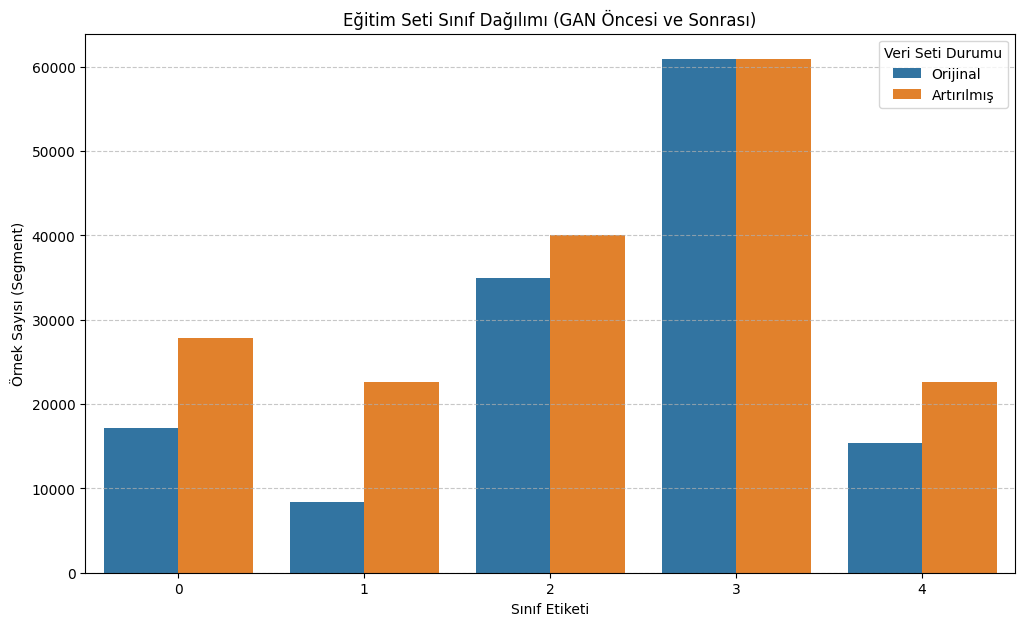

In [9]:
# --- HÜCRE 6: Sınıf Dağılımı Görselleştirmesi (Önce ve Sonra) ---

print("\n--- Sınıf Dağılımı Karşılaştırması (Tüm Sınıflar) ---")

try:
    # Orijinal dağılımı al (Hücre 3'ten global değişken)
    original_labels = list(class_distribution.keys())
    original_counts = list(class_distribution.values())

    # Yeni (Artırılmış) Dağılım
    if 'y_train_orig' in locals() and final_synthetic_labels.size > 0: # Eğer sentetik veri üretildiyse
        augmented_y_train = np.concatenate((y_train_orig, final_synthetic_labels))
        aug_unique, aug_counts = np.unique(augmented_y_train, return_counts=True)
        augmented_distribution = dict(zip(aug_unique, aug_counts))
        augmented_labels = list(augmented_distribution.keys())
        augmented_counts = list(augmented_distribution.values())
        print("\nArtırılmış Eğitim Setindeki Sınıf Dağılımı:")
        print(augmented_distribution)

        # DataFrame oluştur
        df_dist = pd.DataFrame({
            'Sınıf': [str(l) for l in original_labels] + [str(l) for l in augmented_labels],
            'Durum': ['Orijinal'] * len(original_labels) + ['Artırılmış'] * len(augmented_labels),
            'Örnek Sayısı': original_counts + augmented_counts
        })
        hue_order = ['Orijinal', 'Artırılmış']
    else: # Sadece orijinal veriyi göster
        print("Uyarı: Sentetik veri bulunamadı. Sadece orijinal dağılım gösterilecek.")
        df_dist = pd.DataFrame({
            'Sınıf': [str(l) for l in original_labels],
            'Durum': ['Orijinal'] * len(original_labels),
            'Örnek Sayısı': original_counts
        })
        hue_order = ['Orijinal']

    # Görselleştirme
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Sınıf', y='Örnek Sayısı', hue='Durum', data=df_dist,
                order=sorted([str(l) for l in class_distribution.keys()]),
                hue_order=hue_order)
    plt.title('Eğitim Seti Sınıf Dağılımı (GAN Öncesi ve Sonrası)')
    plt.xlabel('Sınıf Etiketi')
    plt.ylabel('Örnek Sayısı (Segment)')
    plt.legend(title='Veri Seti Durumu')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except NameError as e:
    print(f"Hata: Gerekli değişkenler bulunamadı. Önceki hücreleri çalıştırın. {e}")
except FileNotFoundError:
    print("Hata: Gerekli etiket dosyaları (.npy) bulunamadı.")
except Exception as e:
    print(f"Görselleştirme sırasında hata oluştu: {e}")